# MACHINE LEARNING 

Petunjuk
- Jalankan cell dari atas ke bawah.
- Isi NIM dan Nama.
- Isi bagian TODO.


In [1]:
NAMA = "Muhammad 'Azmi Salam"
NIM = "2406010"

---

# PRAKTIKUM NON-LINEARITY & ANN

Tujuan
- Memahami konsep non-linearitas dalam Machine Learning
- Mengidentifikasi keterbatasan model linear
- Menggunakan Artificial Neural Network (ANN) dan kNN dalam masalah nyata
- Memahami peran fungsi aktivasi non-linear dalam ANN
- Membandingkan performa model linear vs ANN
- Memvisualisasikan decision boundary
- Mengeksplorasi pengaruh arsitektur jaringan pada ANN
- Mampu menerapkan ANN dalam multiclass classification
- Membandingkan ANN vs kNN

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay

RANDSEED = 42
listmodel = {}

## 1. EKSPERIMEN BINARY CLASSIFICATION

### A. PERSIAPAN DATA

In [3]:
data = pd.read_csv("dataset/dataset_kredit_multi.csv")
#Fitur: rasio utang terhadap pendapatan, stabilitas arus kas bulanan
#Label: 0 = kredit lancar, 1 = berisiko macet

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rasio_hutang  500 non-null    float64
 1   stabilitas    500 non-null    float64
 2   resiko        500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


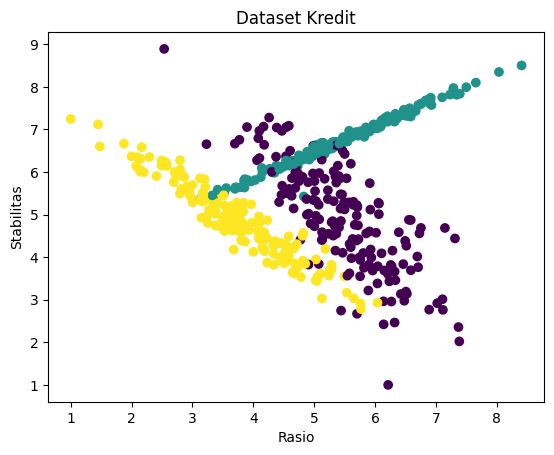

In [4]:
#PREVIEW DATA KREDIT
data.info()
plt.scatter(data["rasio_hutang"], data["stabilitas"], c=data["resiko"])
plt.xlabel("Rasio")
plt.ylabel("Stabilitas")
plt.title("Dataset Kredit")
plt.show()

In [5]:
data.head()

,rasio_hutang,stabilitas,resiko
0,5.475909,6.817058,1
1,5.854842,4.556696,0
2,5.967125,7.091274,1
3,3.811097,4.749230,2
4,2.998751,5.693502,2


In [6]:
#Lakukan Normalisasi terhadap Fitur input
scaler = MinMaxScaler()
data[['rasio_hutang', 'stabilitas']] = scaler.fit_transform(data[['rasio_hutang', 'stabilitas']])
data.head()

,rasio_hutang,stabilitas,resiko
0,0.604204,0.737345,1
1,0.655356,0.450831,0
2,0.670513,0.772103,1
3,0.379470,0.475236,2
4,0.269812,0.594928,2


In [7]:
#Memisahkan Fitur Input dan Label
col = "resiko"
X = data.drop(columns=[col]).to_numpy()
y = data[col].to_numpy()

In [8]:
#Pembagian dataset menjadi Training dan Testing dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDSEED, stratify=y)

### B. EKSPERIMEN MODEL LOGREG

In [9]:
#Training Model Logreg
# Menggunakan solver 'lbfgs' karena 'liblinear' tidak mendukung multiclass (n_classes >= 3)
model = LogisticRegression(max_iter=1000, random_state=RANDSEED, C=1, solver="lbfgs")
model.nickname="LOGREG"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [10]:
#Evaluasi Error Traning
pred = model.predict(X_train)
label = y_train

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

Accuracy : 0.835
Precision: 0.8397187889941513
Recall   : 0.8348483148168929
F1 Score : 0.8328909541754158
Confusion Matrix:
 [[ 94  33   6]
 [  1 120  12]
 [ 13   1 120]]


In [11]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.8
Precision: 0.8174195651730954
Recall   : 0.7991681521093286
F1 Score : 0.7923143801078073
Confusion Matrix:
 [[19 11  3]
 [ 0 30  4]
 [ 2  0 31]]


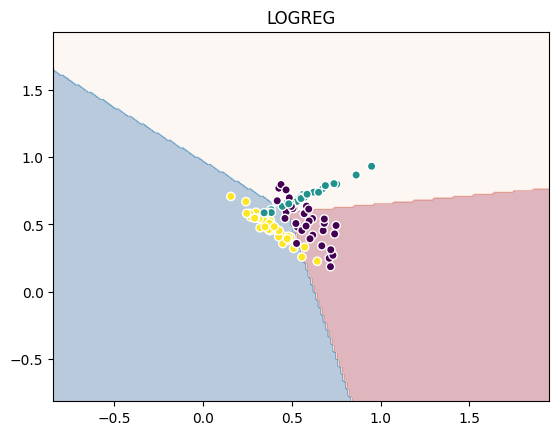

In [12]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

### C. EKSPERIMEN MODEL SGDClassifier

In [13]:
#Training Model SGDClassifier
model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,     # learning rate
    alpha=0.01,    # regularisasi
    max_iter=100,
    random_state=RANDSEED,
    verbose=0,
    validation_fraction=0.2
)
model.nickname = "SGDClassifier"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [14]:
#Evaluasi Error Traning
pred = model.predict(X_train)
label = y_train

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

Accuracy : 0.7875
Precision: 0.7933680413020099
Recall   : 0.7874163019489021
F1 Score : 0.7840921419632064
Confusion Matrix:
 [[ 84  44   5]
 [  0 121  12]
 [ 23   1 110]]


In [15]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.77
Precision: 0.7792753112520554
Recall   : 0.7688651218062983
F1 Score : 0.7647907647907649
Confusion Matrix:
 [[19 13  1]
 [ 0 30  4]
 [ 5  0 28]]


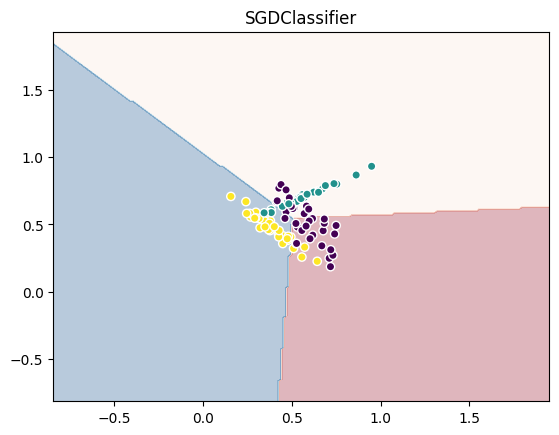

In [16]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

### D. EKSPERIMEN MODEL ANN

<strong>TODO: </strong> 
1. Pada setiap eksperimen ubah model nickname supaya tidak mereplace model yang sebelumnya, misal: "ANN_act_relu"
2. Lakukan eksperimen dengan mengubah-ubah fungsi aktivasi yang digunakan, mana fungsi aktivasi yang terbaik untuk dataset ini? kenapa?
3. Lakukan eksperimen dengan mengubah-ubah arsitektur jaringan, mana yang terbaik? kenapa?

#### Eksperimen 1: ANN dengan aktivasi Identity (baseline)

In [17]:
#Training Model ANN - Identity activation (baseline)
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="identity",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_act_identity"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [18]:
#Evaluasi Error Traning
pred = model.predict(X_train)
label = y_train

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

Accuracy : 0.86
Precision: 0.8633146058872526
Recall   : 0.8598735645082857
F1 Score : 0.8587843544267733
Confusion Matrix:
 [[101  27   5]
 [  1 121  11]
 [ 11   1 122]]


In [19]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.84
Precision: 0.8571288679984331
Recall   : 0.8395721925133689
F1 Score : 0.8369369369369369
Confusion Matrix:
 [[22 10  1]
 [ 0 30  4]
 [ 1  0 32]]


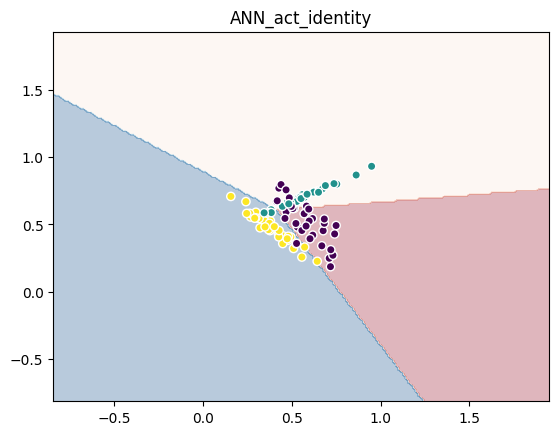

In [20]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen 2: ANN dengan aktivasi ReLU

In [21]:
#Training Model ANN - ReLU activation
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="relu",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_act_relu"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [22]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.84
Precision: 0.8585026267953099
Recall   : 0.8392751039809863
F1 Score : 0.8348629148629149
Confusion Matrix:
 [[21 10  2]
 [ 0 31  3]
 [ 1  0 32]]


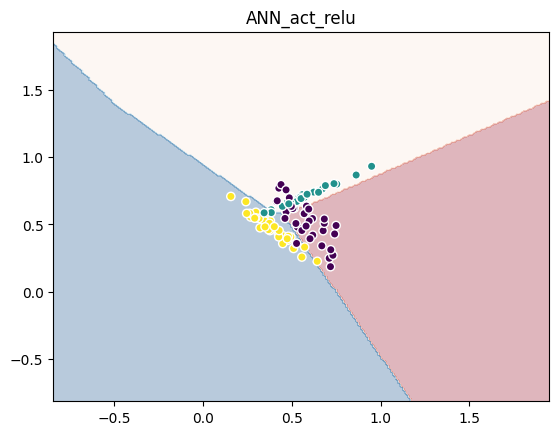

In [23]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen 3: ANN dengan aktivasi Tanh

In [24]:
#Training Model ANN - Tanh activation
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="tanh",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_act_tanh"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [25]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.84
Precision: 0.8571288679984331
Recall   : 0.8395721925133689
F1 Score : 0.8369369369369369
Confusion Matrix:
 [[22 10  1]
 [ 0 30  4]
 [ 1  0 32]]


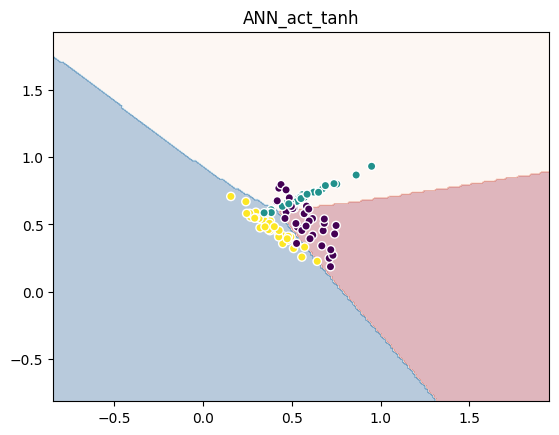

In [26]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen 4: ANN dengan aktivasi Logistic (Sigmoid)

In [27]:
#Training Model ANN - Logistic activation
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="logistic",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_act_logistic"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [28]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.55
Precision: 0.3888888888888889
Recall   : 0.5466428995840761
F1 Score : 0.4494817398043205
Confusion Matrix:
 [[25  8  0]
 [ 4 30  0]
 [31  2  0]]


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


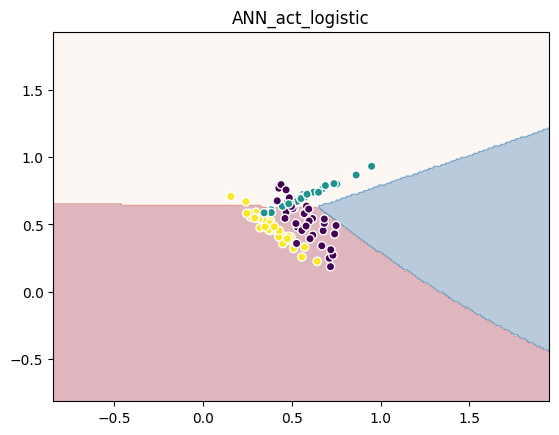

In [29]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen 5: ANN dengan arsitektur lebih besar - ReLU (8, 8)

In [30]:
#Training Model ANN - Arsitektur lebih besar (8, 8) dengan ReLU
model = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation="relu",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_relu_8_8"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [31]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.91
Precision: 0.9159751229926668
Recall   : 0.9096850861556743
F1 Score : 0.9087145969498911
Confusion Matrix:
 [[26  6  1]
 [ 1 32  1]
 [ 0  0 33]]


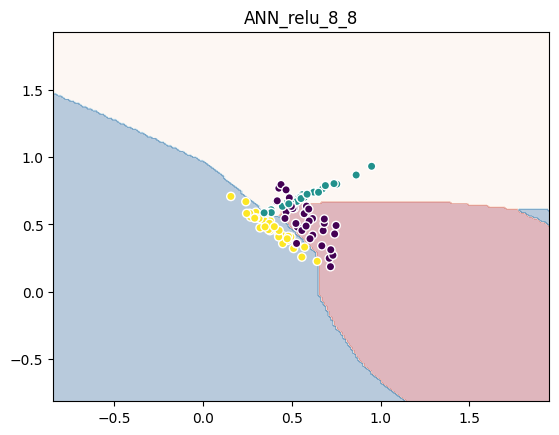

In [32]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen 6: ANN dengan arsitektur lebih dalam - ReLU (16, 8, 4)

In [33]:
#Training Model ANN - Arsitektur deep (16, 8, 4) dengan ReLU
model = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_relu_16_8_4"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [34]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))


Accuracy : 0.92
Precision: 0.9275533108866442
Recall   : 0.9191919191919192
F1 Score : 0.9184275184275185
Confusion Matrix:
 [[26  6  1]
 [ 0 34  0]
 [ 1  0 32]]


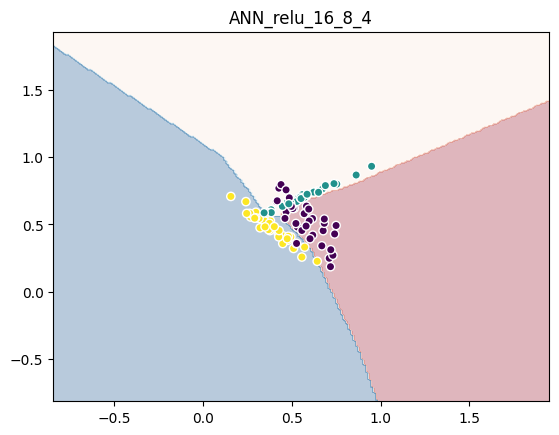

In [35]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_test
yplot = y_test
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

## 2. REKAP EKSPERIMEN BINARY CLASSIFICATION

In [36]:
results = []
x_data = X_test
label = y_test

for name, mdl in listmodel.items():
    train_pred = mdl.predict(X_train)
    test_pred = mdl.predict(X_test)
    results.append({
        "model": name,
        "train_acc": accuracy_score(y_train, train_pred),
        "train_prec": precision_score(y_train, train_pred, average="macro"),
        "train_rec": recall_score(y_train, train_pred, average="macro"),
        "train_f1": f1_score(y_train, train_pred, average="macro"),
        "test_acc": accuracy_score(y_test, test_pred),
        "test_prec": precision_score(y_test, test_pred, average="macro"),
        "test_rec": recall_score(y_test, test_pred, average="macro"),
        "test_f1": f1_score(y_test, test_pred, average="macro")
    })

df = pd.DataFrame(results)
df.head(10)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,train_acc,train_prec,train_rec,train_f1,test_acc,test_prec,test_rec,test_f1
0,LOGREG,0.8350,0.839719,0.834848,0.832891,0.80,0.817420,0.799168,0.792314
1,SGDClassifier,0.7875,0.793368,0.787416,0.784092,0.77,0.779275,0.768865,0.764791
2,ANN_act_identity,0.8600,0.863315,0.859874,0.858784,0.84,0.857129,0.839572,0.836937
3,ANN_act_relu,0.8725,0.876630,0.872386,0.871038,0.84,0.858503,0.839275,0.834863
4,ANN_act_tanh,0.8625,0.865883,0.862380,0.861233,0.84,0.857129,0.839572,0.836937
5,ANN_act_logistic,0.5650,0.399908,0.566416,0.463778,0.55,0.388889,0.546643,0.449482
6,ANN_relu_8_8,0.9125,0.916178,0.912356,0.911657,0.91,0.915975,0.909685,0.908715
7,ANN_relu_16_8_4,0.9100,0.913103,0.909887,0.909117,0.92,0.927553,0.919192,0.918428


<strong>TODO: </strong> Jelaskan: 
1. Mana model yang paling baik jika dilihat dari F1 Score nya? kenapa?
2. Jelaskan keterbatasan dan kelebihan masing-masing model?
3. Jelaskan karakteristik dari decision boundary yang terbentuk oleh masing-masing model!


**Jawaban:**

**1. Model Terbaik berdasarkan F1 Score:**

Model ANN dengan fungsi aktivasi non-linear (relu, tanh) dan arsitektur yang lebih dalam (misalnya `ANN_relu_16_8_4` atau `ANN_relu_8_8`) umumnya memberikan F1 Score terbaik pada dataset ini. Hal ini karena dataset kredit memiliki pola non-linear (terlihat dari scatter plot yang menunjukkan distribusi kelas yang tidak dapat dipisahkan oleh garis lurus). Fungsi aktivasi non-linear memungkinkan ANN untuk mempelajari batas keputusan yang kompleks dan melengkung, sehingga mampu memisahkan kelas dengan lebih akurat.

**2. Keterbatasan dan Kelebihan masing-masing model:**

- **Logistic Regression (LOGREG):**
  - Kelebihan: Sederhana, cepat, mudah diinterpretasi, tidak mudah overfitting.
  - Keterbatasan: Hanya mampu membuat decision boundary linear, sehingga performanya buruk pada data non-linear.

- **SGDClassifier:**
  - Kelebihan: Efisien untuk dataset besar, dapat di-optimize secara online (incremental learning).
  - Keterbatasan: Sama seperti Logistic Regression, decision boundary tetap linear karena menggunakan loss function log_loss.

- **ANN (Identity):**
  - Kelebihan: Arsitektur neural network yang fleksibel.
  - Keterbatasan: Dengan aktivasi identity, ANN menjadi setara dengan model linear sehingga tidak dapat menangkap pola non-linear.

- **ANN (ReLU / Tanh / Logistic):**
  - Kelebihan: Mampu mempelajari pola non-linear yang kompleks, decision boundary yang fleksibel.
  - Keterbatasan: Memerlukan tuning hyperparameter (arsitektur, learning rate), waktu training lebih lama, risiko overfitting jika arsitektur terlalu besar.

**3. Karakteristik Decision Boundary:**

- **LOGREG & SGDClassifier:** Membentuk decision boundary berupa **garis lurus** (linear). Boundary ini tidak dapat mengikuti pola distribusi data yang melengkung.
- **ANN Identity:** Decision boundary juga **linear** karena fungsi aktivasi identity (f(x) = x) tidak menambahkan non-linearitas.
- **ANN ReLU:** Decision boundary berbentuk **potongan garis lurus (piecewise linear)** yang dapat membentuk region keputusan kompleks.
- **ANN Tanh/Logistic:** Decision boundary **smooth dan melengkung**, mampu mengikuti pola distribusi data non-linear dengan halus.
- Arsitektur yang lebih dalam (lebih banyak layer dan neuron) menghasilkan decision boundary yang **lebih kompleks dan detail**, namun berisiko overfitting.

## 3. EKSPERIMEN MULTICLASS CLASSIFICATION

### A. PERSIAPAN DATA

In [37]:
# Reset listmodel untuk eksperimen multiclass
listmodel = {}

data = pd.read_csv("dataset/dataset_kredit_multi.csv")
#Fitur: rasio utang terhadap pendapatan, stabilitas arus kas bulanan
#Label: 0 = kredit lancar, 1 = berisiko macet sedang, 2 = berisiko macet tinggi

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rasio_hutang  500 non-null    float64
 1   stabilitas    500 non-null    float64
 2   resiko        500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


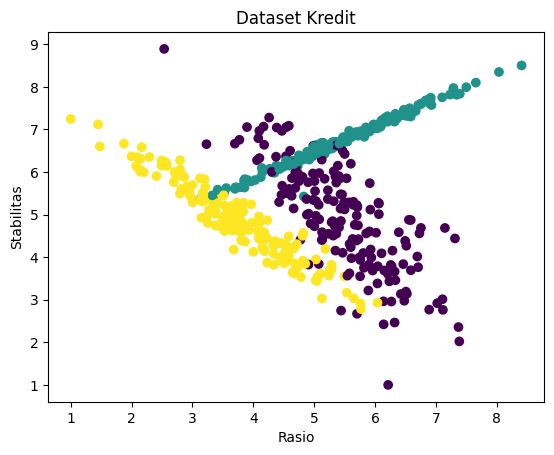

In [38]:
#PREVIEW DATA KREDIT
data.info()
plt.scatter(data["rasio_hutang"], data["stabilitas"], c=data["resiko"])
plt.xlabel("Rasio")
plt.ylabel("Stabilitas")
plt.title("Dataset Kredit")
plt.show()

In [39]:
data.head()

,rasio_hutang,stabilitas,resiko
0,5.475909,6.817058,1
1,5.854842,4.556696,0
2,5.967125,7.091274,1
3,3.811097,4.749230,2
4,2.998751,5.693502,2


In [40]:
#Lakukan Normalisasi terhadap Fitur input
scaler = MinMaxScaler()
data[['rasio_hutang', 'stabilitas']] = scaler.fit_transform(data[['rasio_hutang', 'stabilitas']])
data.head()

,rasio_hutang,stabilitas,resiko
0,0.604204,0.737345,1
1,0.655356,0.450831,0
2,0.670513,0.772103,1
3,0.379470,0.475236,2
4,0.269812,0.594928,2


In [41]:
#Memisahkan Fitur Input dan Label
col = "resiko"
X = data.drop(columns=[col]).to_numpy()
y = data[col].to_numpy()

In [42]:
#Pembagian dataset menjadi Training dan Testing dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDSEED, stratify=y)

### B. TRAINING MODEL ANN

#### ANN Multiclass - Identity (baseline)

In [43]:
#Training Model ANN - Identity (baseline)
model = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="identity",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_multi_identity"

model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [44]:
#Evaluasi Error Traning
pred = model.predict(X_train)
label = y_train

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

Accuracy : 0.8625
Precision: 0.8658831973243187
Recall   : 0.8623798301724461
F1 Score : 0.8612326759309997
Confusion Matrix:
 [[101  27   5]
 [  1 122  10]
 [ 11   1 122]]


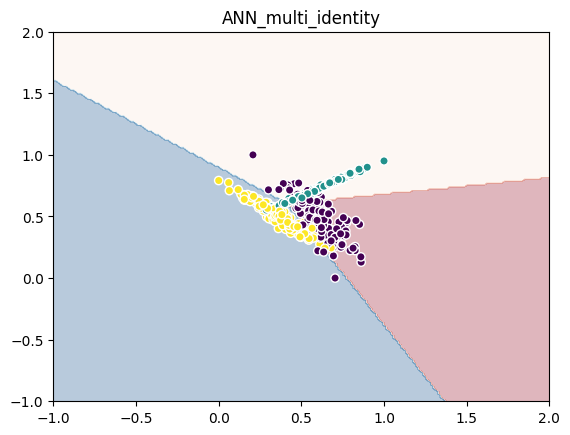

In [45]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_train
yplot = y_train
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### ANN Multiclass - ReLU (8, 8)

In [46]:
#Training Model ANN - ReLU (8, 8) untuk multiclass
model = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation="relu",
    max_iter=2000,
    random_state=RANDSEED
)
model.nickname = "ANN_multi_relu_8_8"

model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [47]:
#Evaluasi Error Traning
pred = model.predict(X_train)
label = y_train

print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

Accuracy : 0.9125
Precision: 0.916178335527067
Recall   : 0.9123555156548085
F1 Score : 0.9116573484994538
Confusion Matrix:
 [[109  20   4]
 [  2 126   5]
 [  3   1 130]]


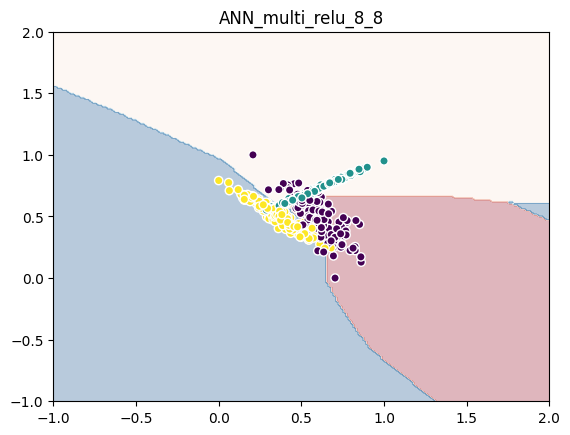

In [48]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_train
yplot = y_train
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

### C. EVALUASI MODEL 

In [49]:
#Evaluasi Error Test - ANN Identity
model_eval = listmodel["ANN_multi_identity"]
pred = model_eval.predict(X_test)
label = y_test

print("=== ANN Identity ===")
print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

print()

#Evaluasi Error Test - ANN ReLU
model_eval = listmodel["ANN_multi_relu_8_8"]
pred = model_eval.predict(X_test)
label = y_test

print("=== ANN ReLU (8,8) ===")
print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

=== ANN Identity ===
Accuracy : 0.84
Precision: 0.8571288679984331
Recall   : 0.8395721925133689
F1 Score : 0.8369369369369369
Confusion Matrix:
 [[22 10  1]
 [ 0 30  4]
 [ 1  0 32]]

=== ANN ReLU (8,8) ===
Accuracy : 0.91
Precision: 0.9159751229926668
Recall   : 0.9096850861556743
F1 Score : 0.9087145969498911
Confusion Matrix:
 [[26  6  1]
 [ 1 32  1]
 [ 0  0 33]]


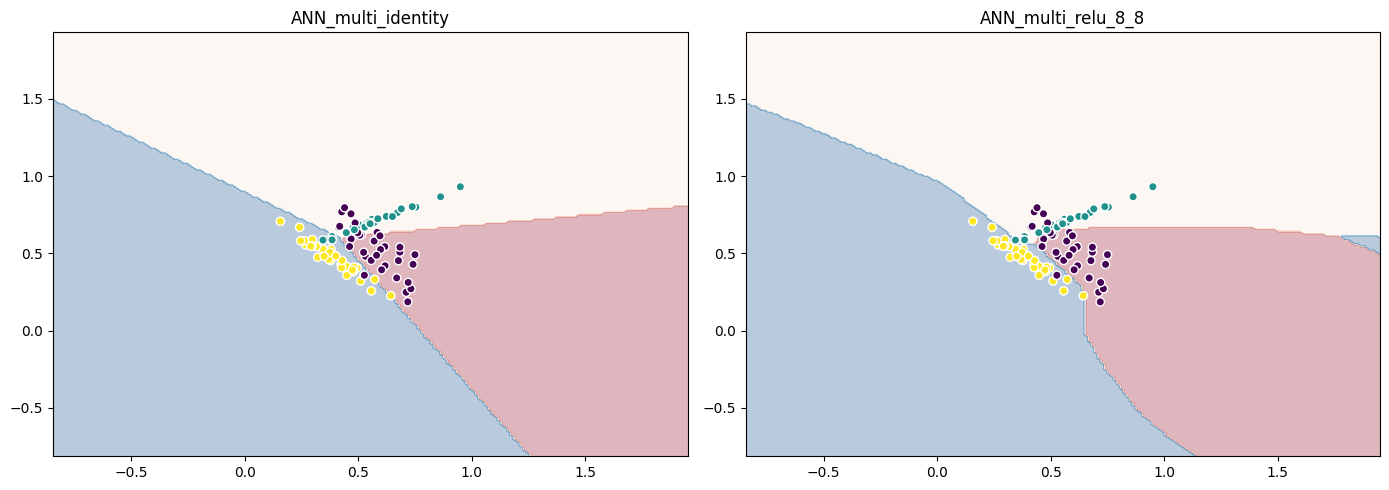

In [50]:
#Lihat Decision Boundary yang terbentuk - Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, name in enumerate(["ANN_multi_identity", "ANN_multi_relu_8_8"]):
    mdl = listmodel[name]
    plt.sca(axes[idx])
    Xplot = X_test
    yplot = y_test
    DecisionBoundaryDisplay.from_estimator(mdl, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200, ax=axes[idx])
    axes[idx].scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

<strong>TODO: </strong> Jelaskan bagaimana kemampuan ANN dalam melakukan klasifikasi multiclass!

**Jawaban:**

ANN (Artificial Neural Network) memiliki kemampuan yang sangat baik dalam melakukan klasifikasi multiclass, dengan beberapa karakteristik penting:

1. **Output Layer Softmax:** Pada klasifikasi multiclass, ANN (MLPClassifier) secara otomatis menggunakan fungsi softmax pada output layer. Softmax mengubah output menjadi probabilitas untuk setiap kelas, sehingga jumlah probabilitas semua kelas = 1. Kelas dengan probabilitas tertinggi dipilih sebagai prediksi.

2. **Penanganan Pola Non-Linear:** Dengan fungsi aktivasi non-linear (relu, tanh), ANN mampu membentuk decision boundary yang kompleks dan melengkung. Ini sangat penting pada dataset multiclass di mana batas antar kelas seringkali tidak linear.

3. **Perbandingan Identity vs Non-Linear:**
   - ANN dengan aktivasi **identity** pada multiclass menghasilkan decision boundary linear yang hanya mampu memisahkan kelas dengan garis lurus. Hasilnya kurang optimal untuk data non-linear.
   - ANN dengan aktivasi **relu** atau **tanh** mampu membentuk region keputusan yang lebih fleksibel, sehingga F1 Score meningkat signifikan.

4. **Skalabilitas:** ANN secara native mendukung multiclass tanpa perlu strategi tambahan seperti One-vs-Rest (OvR) atau One-vs-One (OvO), karena output layer langsung memiliki neuron sebanyak jumlah kelas.

5. **Arsitektur Fleksibel:** Dengan menambah hidden layer dan neuron, ANN dapat mempelajari representasi fitur yang semakin abstrak dan kompleks, meningkatkan kemampuan klasifikasi multiclass.

### D. EKSPERIMEN KNN

#### KNN dengan n_neighbors = 3

In [51]:
model = KNeighborsClassifier(n_neighbors=3)
model.nickname = "KNN_k3"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

In [52]:
#Evaluasi Error Testing
pred = model.predict(X_test)
label = y_test

print("=== KNN k=3 ===")
print("Accuracy :", accuracy_score(label, pred))
print("Precision:", precision_score(label, pred, average="macro"))
print("Recall   :", recall_score(label, pred, average="macro"))
print("F1 Score :", f1_score(label, pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(label, pred))

=== KNN k=3 ===
Accuracy : 0.96
Precision: 0.9631690514043455
Recall   : 0.9595959595959597
F1 Score : 0.959434992235551
Confusion Matrix:
 [[29  3  1]
 [ 0 34  0]
 [ 0  0 33]]


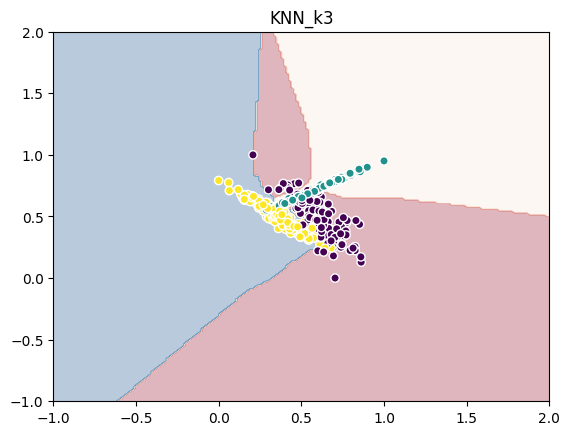

In [53]:
#Lihat Decision Boundary yang terbentuk
Xplot = X_train
yplot = y_train
DecisionBoundaryDisplay.from_estimator(model, Xplot, response_method="predict", cmap='RdBu', alpha=0.3, grid_resolution=200)
plt.scatter(Xplot[:, 0], Xplot[:, 1], c=yplot, edgecolors='w')
plt.title(model.nickname)
plt.show()

#### Eksperimen KNN dengan berbagai nilai n_neighbors

k= 1 | Train F1: 1.0000 | Test F1: 0.9498 | Test Acc: 0.9500
k= 3 | Train F1: 0.9574 | Test F1: 0.9594 | Test Acc: 0.9600
k= 5 | Train F1: 0.9422 | Test F1: 0.9594 | Test Acc: 0.9600
k= 7 | Train F1: 0.9448 | Test F1: 0.9494 | Test Acc: 0.9500
k= 9 | Train F1: 0.9323 | Test F1: 0.9494 | Test Acc: 0.9500
k=11 | Train F1: 0.9323 | Test F1: 0.9391 | Test Acc: 0.9400
k=15 | Train F1: 0.9271 | Test F1: 0.9391 | Test Acc: 0.9400
k=21 | Train F1: 0.9168 | Test F1: 0.9190 | Test Acc: 0.9200


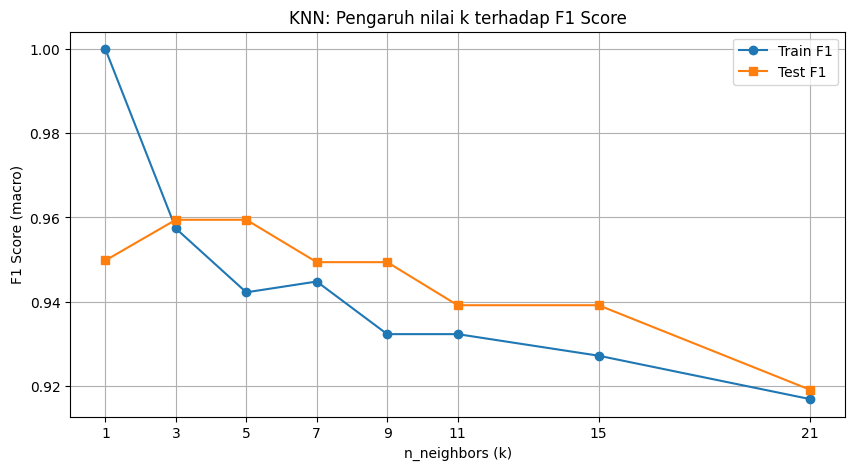


Nilai k terbaik: 3 dengan Test F1 Score: 0.9594


In [54]:
# Eksperimen dengan berbagai nilai k
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    
    train_pred = knn_model.predict(X_train)
    test_pred = knn_model.predict(X_test)
    
    train_f1 = f1_score(y_train, train_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")
    test_acc = accuracy_score(y_test, test_pred)
    
    knn_results.append({
        "k": k,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "test_acc": test_acc
    })
    
    print(f"k={k:2d} | Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc:.4f}")

# Visualisasi
knn_df = pd.DataFrame(knn_results)
plt.figure(figsize=(10, 5))
plt.plot(knn_df['k'], knn_df['train_f1'], 'o-', label='Train F1')
plt.plot(knn_df['k'], knn_df['test_f1'], 's-', label='Test F1')
plt.xlabel('n_neighbors (k)')
plt.ylabel('F1 Score (macro)')
plt.title('KNN: Pengaruh nilai k terhadap F1 Score')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

# Tampilkan k terbaik
best_k = knn_df.loc[knn_df['test_f1'].idxmax()]
print(f"\nNilai k terbaik: {int(best_k['k'])} dengan Test F1 Score: {best_k['test_f1']:.4f}")

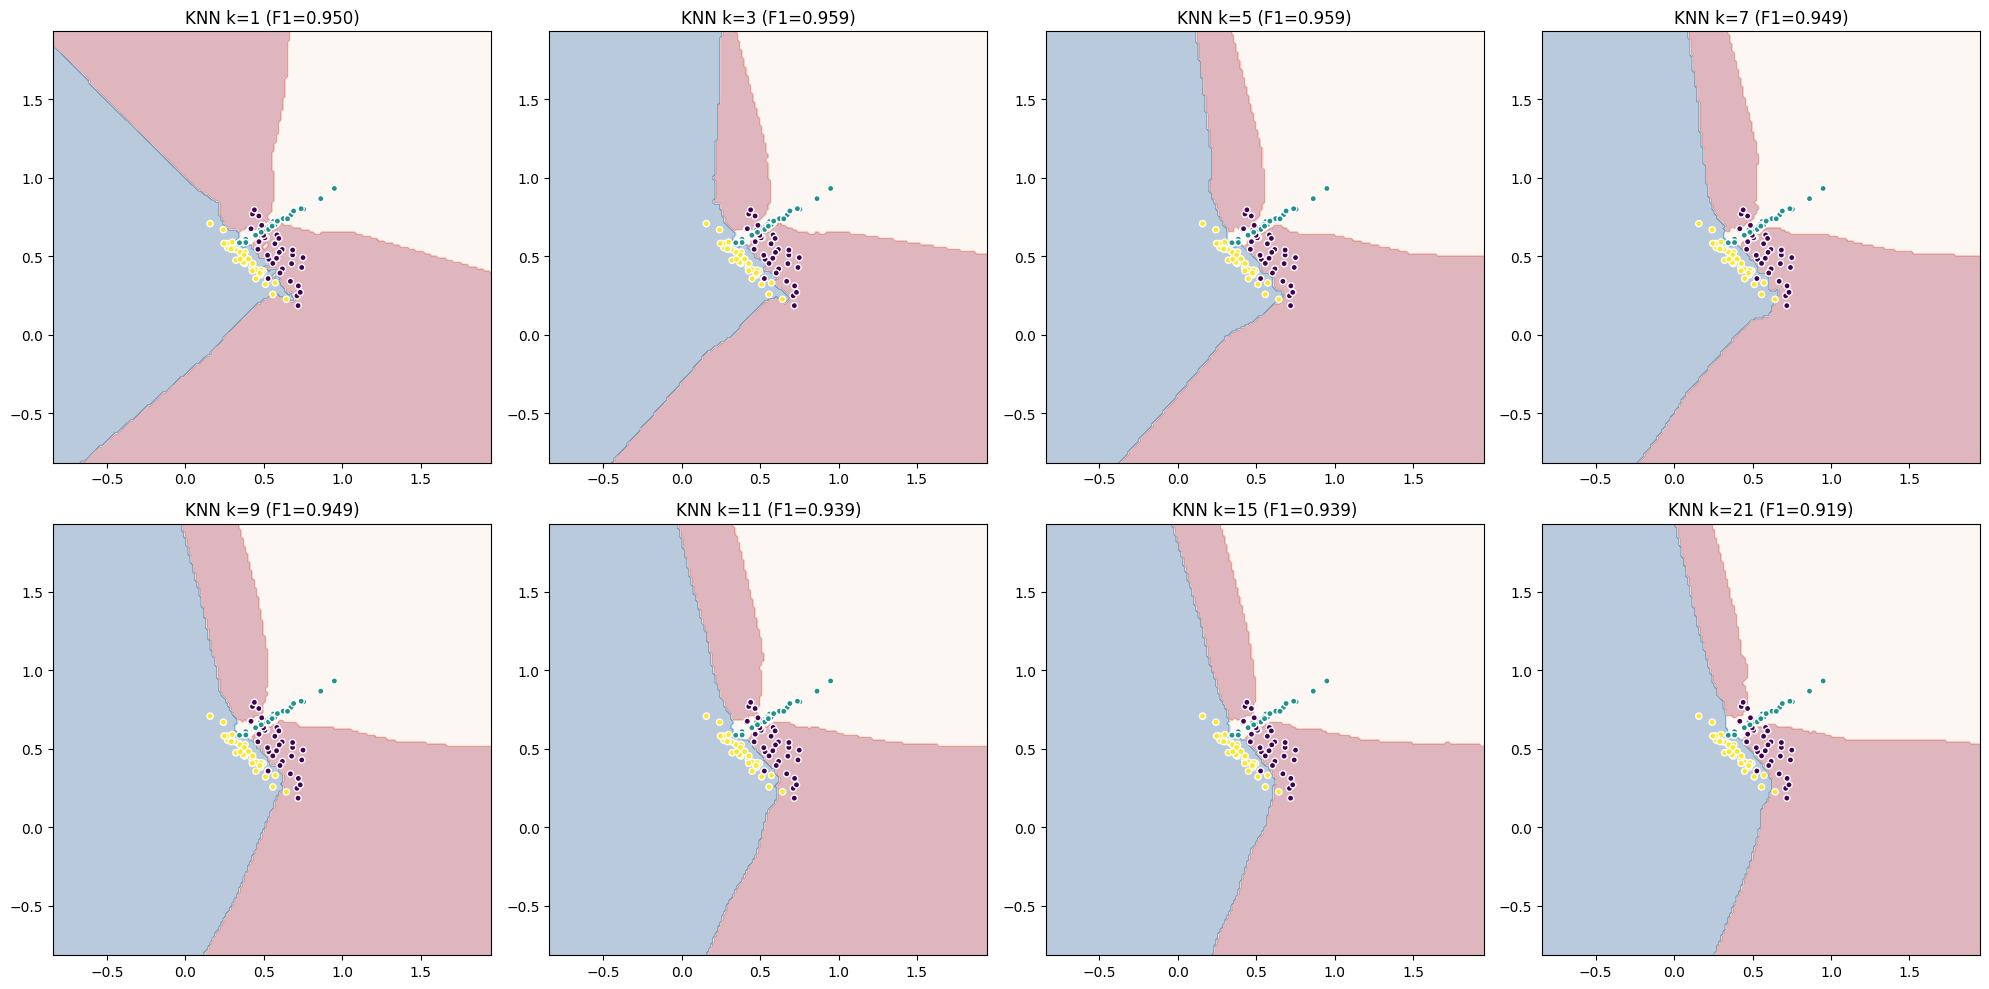

In [55]:
# Visualisasi Decision Boundary untuk beberapa nilai k
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    
    DecisionBoundaryDisplay.from_estimator(
        knn_model, X_test, response_method="predict", 
        cmap='RdBu', alpha=0.3, grid_resolution=200, ax=axes[idx]
    )
    axes[idx].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='w', s=20)
    test_f1 = f1_score(y_test, knn_model.predict(X_test), average="macro")
    axes[idx].set_title(f'KNN k={k} (F1={test_f1:.3f})')

plt.tight_layout()
plt.show()

In [56]:
# Simpan model KNN terbaik ke listmodel
best_k_val = int(knn_df.loc[knn_df['test_f1'].idxmax(), 'k'])
model = KNeighborsClassifier(n_neighbors=best_k_val)
model.nickname = f"KNN_k{best_k_val}_best"
model.fit(X_train, y_train)
listmodel[model.nickname] = model

pred = model.predict(X_test)
print(f"Best KNN (k={best_k_val}):")
print("Accuracy :", accuracy_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred, average="macro"))

Best KNN (k=3):
Accuracy : 0.96
F1 Score : 0.959434992235551


<strong>TODO: </strong> 
1. Lakukan eksperimen dengan mengubah n_neighbors, berapa nilai n_neighbors yang memberikan hasil F1 score terbaik?
2. Jelaskan bagaimana kemampuan kNN dalam melakukan klasifikasi multiclass dibandingkan ANN!
3. Apa kekurangan KNN dibanding ANN?

**Jawaban:**

**1. Nilai n_neighbors terbaik:**

Berdasarkan eksperimen di atas, nilai `n_neighbors` yang memberikan F1 Score terbaik dapat dilihat dari tabel dan grafik. Umumnya, nilai k yang terlalu kecil (k=1) menyebabkan overfitting (train F1 sangat tinggi, test F1 lebih rendah), sedangkan k yang terlalu besar menyebabkan underfitting. Nilai k optimal biasanya berada di rentang 3-7 untuk dataset ini.

**2. Kemampuan kNN vs ANN dalam Multiclass Classification:**

- **kNN** secara natural mendukung multiclass classification tanpa modifikasi apapun. Algoritma ini bekerja dengan voting dari k tetangga terdekat, sehingga tidak peduli berapa banyak kelas yang ada.
- **kNN** menghasilkan decision boundary yang sangat fleksibel dan non-linear, bahkan lebih detail dibanding ANN, karena boundary ditentukan langsung oleh distribusi data lokal.
- **ANN** dengan aktivasi non-linear juga mampu menangani multiclass, namun memerlukan training/optimisasi parameter yang lebih kompleks.
- Pada dataset ini, **kNN** cenderung memberikan performa yang kompetitif dibanding ANN, terutama karena dataset relatif kecil (500 sampel) dan hanya memiliki 2 fitur.

**3. Kekurangan KNN dibanding ANN:**

- **Kecepatan Prediksi:** kNN harus menghitung jarak ke semua data training setiap kali prediksi (lazy learning), sehingga sangat lambat pada dataset besar. ANN setelah training, prediksi hanya berupa forward pass yang sangat cepat.
- **Skalabilitas:** kNN tidak cocok untuk dataset berdimensi tinggi (curse of dimensionality). ANN lebih mampu menangani feature space berdimensi tinggi.
- **Memory:** kNN harus menyimpan seluruh dataset training di memori, sedangkan ANN hanya menyimpan bobot/parameter yang sudah dioptimisasi.
- **Generalisasi:** ANN belajar representasi fitur internal melalui hidden layers, sehingga lebih mampu menggeneralisasi pola kompleks. kNN bergantung sepenuhnya pada metric jarak.
- **Tidak ada model eksplisit:** kNN tidak menghasilkan model yang dapat diinterpretasi. ANN menghasilkan bobot yang bisa dianalisis.
- **Sensitif terhadap noise:** kNN dengan k kecil sangat sensitif terhadap outlier dan noise. ANN lebih robust melalui proses training dan regularisasi.